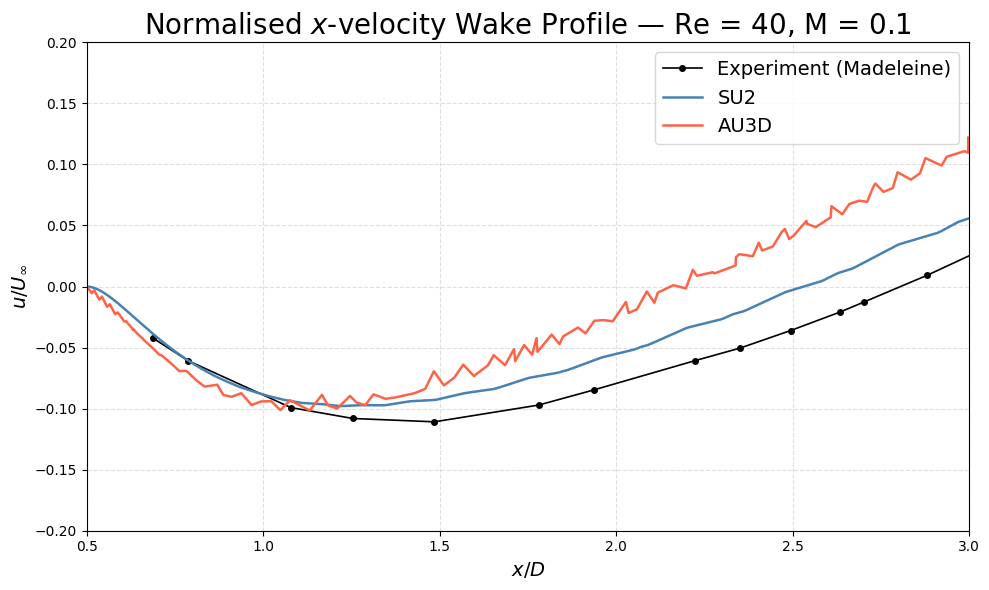

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Try to import AU3D utilities (optional) ───────────────────────────
try:
    from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
    from matplotlib.tri import Triangulation
    HAS_AU3D = True
except ImportError:
    HAS_AU3D = False
    print("pyau3d not found — skipping AU3D data.")

# ── Parameters ────────────────────────────────────────────────────────
RE         = 40
U_farfield = 34.0297   # m/s  (U∞)
D          = 1.0       # cylinder diameter

# AU3D mesh: cylinder centre at x = 0
# SU2 mesh:  cylinder centre at x = 0.5
au3d_x_center = 0.0
su2_x_center  = 0.5

# Wake line sample bounds (AU3D)
x_line_start = 0.0
x_line_end   = 3.0
y_line       = 0.0
tolerance    = 1e-1   # y-tolerance for centreline filter

# ══════════════════════════════════════════════════════════════════════
# SU2 — load CSV line probe
# ══════════════════════════════════════════════════════════════════════
data_dir = "/home/ahf25/git/global_stability/data/Re40"
df = pd.read_csv(f"{data_dir}/su2_u_profile_Re40.csv")
df_su2 = df[df['vtkValidPointMask'] == 1].copy()

x_su2  = df_su2['Points_0'].values
ux_su2 = df_su2['Velocity_0'].values

x_su2_norm = (x_su2 - su2_x_center) / D   # x/D  (0 = cylinder centre)
u_su2_norm = ux_su2 / U_farfield           # u/U∞

idx          = np.argsort(x_su2_norm)
x_su2_sorted = x_su2_norm[idx]
u_su2_sorted = u_su2_norm[idx]

# ══════════════════════════════════════════════════════════════════════
# AU3D — extract wake centreline from volume mesh
# ══════════════════════════════════════════════════════════════════════
if HAS_AU3D:
    cfd_dir = f"/home/ahf25/CFD_2d_cylinder_all/Steady/2d_cylinder_21228_Re{RE}"
    pltfile = PltFileUtils(cfd_dir + "/cylinder.plt")
    rstfile = UnkFileUtils(cfd_dir + "/cylinder.rst", extend=False)

    side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=3)
    rstfile._primitive()
    side_ux = rstfile.ux[side_nodes]

    # Filter centreline nodes: x in [x_line_start, x_line_end], y ≈ 0
    line_filter = (
        (side_coords[:, 0] >= x_line_start) &
        (side_coords[:, 0] <= x_line_end)   &
        (np.abs(side_coords[:, 1] - y_line) < tolerance)
    )

    x_au3d  = side_coords[line_filter, 0]
    ux_au3d = side_ux[line_filter]

    x_au3d_norm = (x_au3d - au3d_x_center) / D   # x/D
    u_au3d_norm = ux_au3d / U_farfield            # u/U∞

    idx_au3d       = np.argsort(x_au3d_norm)
    x_au3d_sorted  = x_au3d_norm[idx_au3d]
    u_au3d_sorted  = u_au3d_norm[idx_au3d]

# ══════════════════════════════════════════════════════════════════════
# Experimental data
# ══════════════════════════════════════════════════════════════════════
exp1 = pd.read_csv(f"{data_dir}/U_profile_Re40_MADELEINE.csv")
# exp2 = pd.read_csv("../../data/Re40/U_profile_Re40_Nieuwstadt _Keller.csv")

# ══════════════════════════════════════════════════════════════════════
# Plot
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(exp1["x"]+0.5, exp1[" y"],
        color='black', marker='o', markersize=4, linewidth=1.2,
        label='Experiment (Madeleine)')

# Uncomment to add second dataset:
# ax.plot(exp2["x"], exp2[" y"],
#         color='dimgray', marker='s', markersize=4, linewidth=1.2,
#         label='Experiment (Keller)')

ax.plot(x_su2_sorted, u_su2_sorted,
        color='steelblue', linewidth=1.8,
        label='SU2')

if HAS_AU3D:
    ax.plot(x_au3d_sorted, u_au3d_sorted,
            color='tomato', linewidth=1.8,
            label='AU3D')

# ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
# ax.axhline(1, color='gray', linewidth=0.8, linestyle='--', label=r'$u/U_\infty = 1$')
# ax.axvline(0, color='black', linewidth=0.8, linestyle=':', label='Cylinder centre')

ax.set_xlabel(r'$x/D$', fontsize=14)
ax.set_ylabel(r'$u / U_\infty$', fontsize=14)
ax.set_title(rf'Normalised $x$-velocity Wake Profile — Re = {RE}, M = 0.1', fontsize=20)
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0.5,3)
ax.set_ylim(-0.2,0.2)
plt.tight_layout()
plt.savefig("u_profile_combined.png", dpi=150)
plt.show()